/tmp/ipykernel_31304/3725051593.py:8: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_out  = xr.open_dataset(nc_file)


<xarray.Dataset> Size: 74MB
Dimensions:       (year: 28, lat: 144, lon: 192)
Coordinates:
  * year          (year) int64 224B 1985 1986 1987 1988 ... 2009 2010 2011 2012
  * lat           (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon           (lon) float64 2kB 0.9375 2.812 4.688 ... 355.3 357.2 359.1
Data variables:
    onset_jday    (year, lat, lon) float64 6MB ...
    onset_day     (year, lat, lon) float64 6MB ...
    onset_month   (year, lat, lon) float64 6MB ...
    onset_year    (year, lat, lon) float64 6MB ...
    demise_jday   (year, lat, lon) float64 6MB ...
    demise_day    (year, lat, lon) float64 6MB ...
    demise_month  (year, lat, lon) float64 6MB ...
    demise_year   (year, lat, lon) float64 6MB ...
    totwet        (year, lat, lon) float64 6MB ...
    totdry        (year, lat, lon) float64 6MB ...
    durwet        (year, lat, lon) timedelta64[ns] 6MB ...
    durdry        (year, lat, lon) timedelta64[ns] 6MB ...
Attributes:
    model:       U

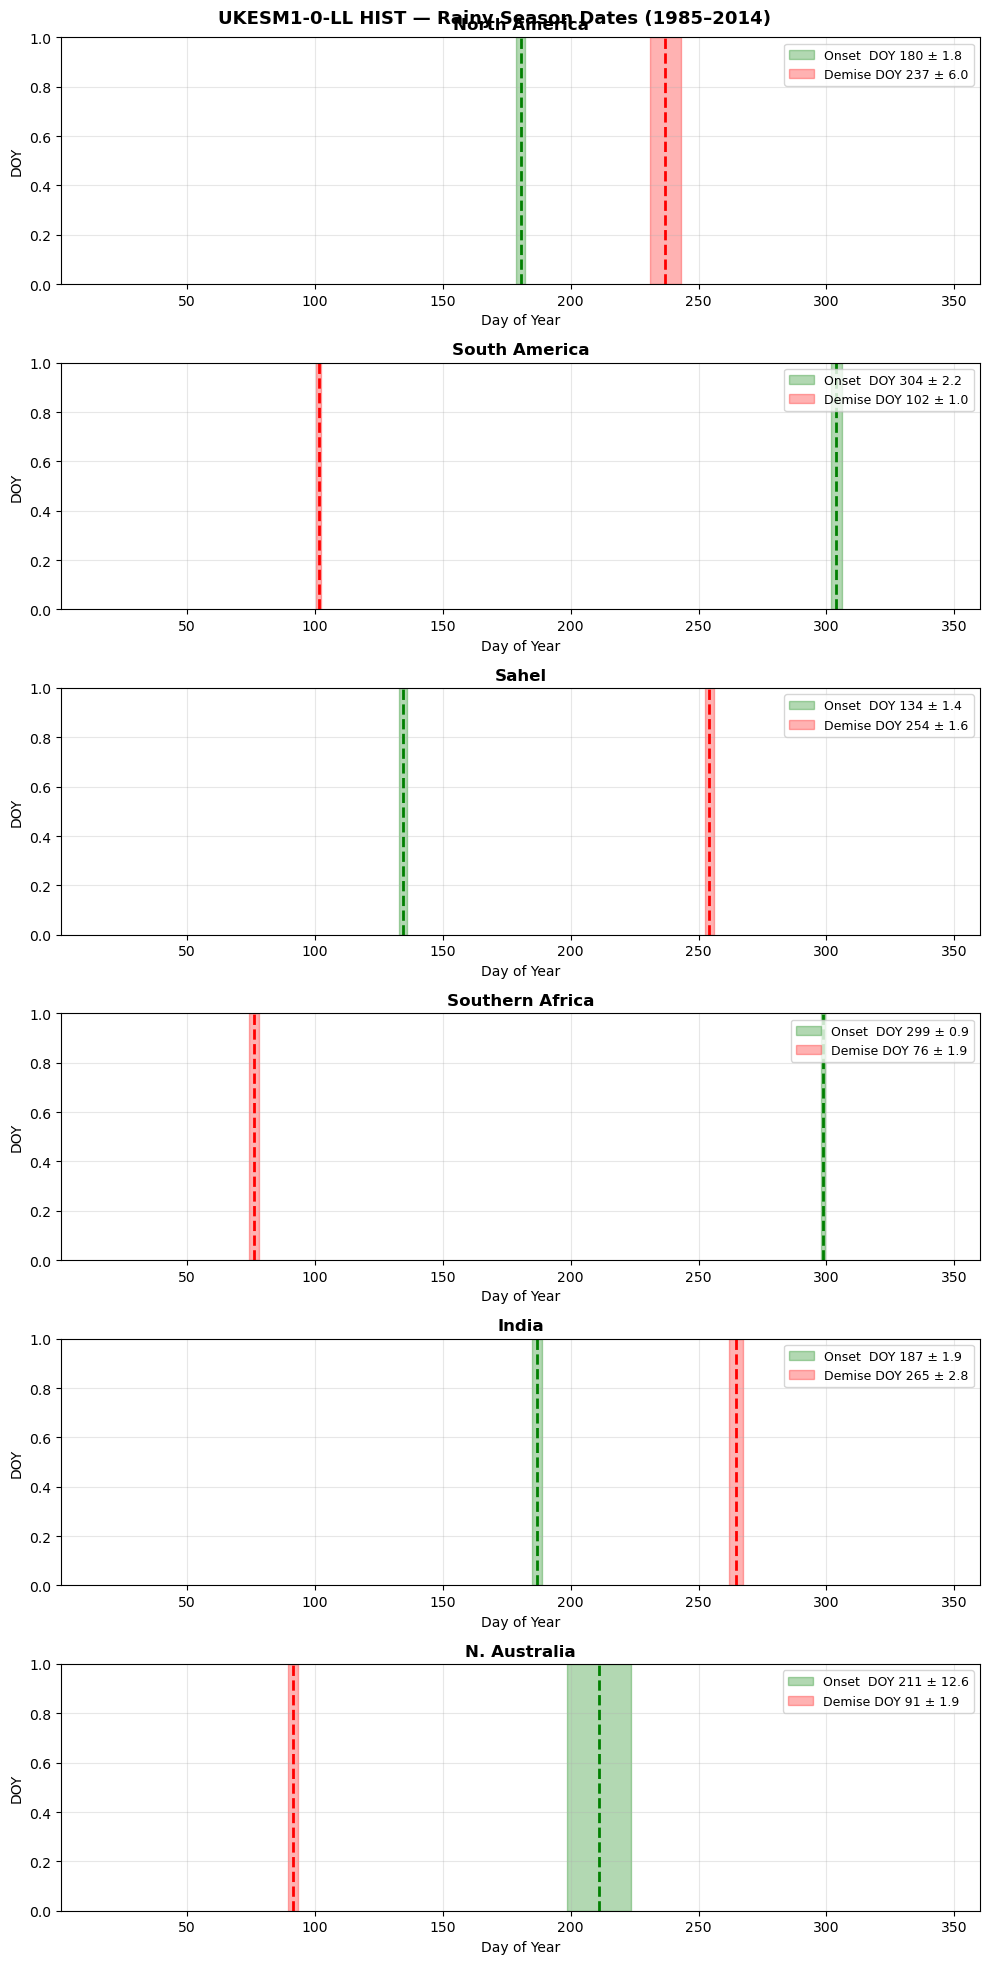

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Load the file ─────────────────────────────────────────────────────────────
nc_file = Path("~/UoE/20260218_Monsoons/rainyseason_output_files/rainy_season_UKESM1-0-LL_HIST_1985-2014.nc").expanduser()
ds_out  = xr.open_dataset(nc_file)
missval = -999.0

lats = ds_out.lat.values
lons = ds_out.lon.values
model_name = ds_out.attrs["model"]
exp        = ds_out.attrs["experiment"]
out_dir    = nc_file.parent

print(ds_out)

# ── Domain definitions ────────────────────────────────────────────────────────
domains = {
    "North America":   {"lat": (18.0,  33.0),  "lon": (248.0, 258.0)},
    "South America":   {"lat": (-18.5, -7.0),  "lon": (300.0, 318.0)},
    "Sahel":           {"lat": (7.0,   18.5),  "lon": (0.0,   40.0)},
    "Southern Africa": {"lat": (-18.5, -7.0),  "lon": (19.5,  31.0)},
    "India":           {"lat": (15.0,  27.0),  "lon": (73.0,  87.0)},
    "N. Australia":    {"lat": (-21.0, -9.5),  "lon": (120.5, 149.0)},
}

# ── Reconstruct smoothed annual cycle from onset/demise jday ─────────────────
# NOTE: 'smoothed' array from Step 3 is not saved in the NetCDF.
# We reconstruct the climatological mean annual cycle directly from ds_out
# using onset_jday as a proxy check, but for the cycle we use the raw
# DOY climatology from onset/demise patterns.
# Best option: reload prec and recompute, OR just plot raw DOY climatology.
# Here we plot mean onset/demise only — add smoothed cycle if prec is available.

fig, axes = plt.subplots(6, 1, figsize=(10, 20))

for ax, (region, dom) in zip(axes.flat, domains.items()):
    lat_min, lat_max = dom["lat"]
    lon_min, lon_max = dom["lon"]

    ilat = np.where((lats >= lat_min) & (lats <= lat_max))[0]
    ilon = np.where((lons >= lon_min) & (lons <= lon_max))[0]

    # Onset / demise
    onset_domain  = ds_out["onset_jday"].values[:, ilat, :][:, :, ilon].copy().astype(float)
    demise_domain = ds_out["demise_jday"].values[:, ilat, :][:, :, ilon].copy().astype(float)
    onset_domain[onset_domain   == missval] = np.nan
    demise_domain[demise_domain == missval] = np.nan

    onset_yearly  = np.nanmean(onset_domain,  axis=(1, 2))
    demise_yearly = np.nanmean(demise_domain, axis=(1, 2))

    n_onset  = np.sum(~np.isnan(onset_yearly))
    n_demise = np.sum(~np.isnan(demise_yearly))

    mean_onset  = np.nanmean(onset_yearly)
    mean_demise = np.nanmean(demise_yearly)
    se_onset    = np.nanstd(onset_yearly)  / np.sqrt(n_onset)  if n_onset  > 1 else 0
    se_demise   = np.nanstd(demise_yearly) / np.sqrt(n_demise) if n_demise > 1 else 0

    # Onset/demise lines only (no smoothed cycle — smoothed not saved in NC)
    ax.axvline(mean_onset,  color="green", linewidth=2, linestyle="--")
    ax.axvspan(mean_onset  - se_onset,  mean_onset  + se_onset,
               alpha=0.3, color="green",
               label=f"Onset  DOY {mean_onset:.0f} ± {se_onset:.1f}")
    ax.axvline(mean_demise, color="red",   linewidth=2, linestyle="--")
    ax.axvspan(mean_demise - se_demise, mean_demise + se_demise,
               alpha=0.3, color="red",
               label=f"Demise DOY {mean_demise:.0f} ± {se_demise:.1f}")

    ax.set_title(f"{region}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Day of Year")
    ax.set_ylabel("DOY")
    ax.set_xlim(1, 360)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, alpha=0.3)

plt.suptitle(f"{model_name} {exp} — Rainy Season Dates (1985–2014)", fontsize=13, fontweight="bold")
plt.tight_layout()
# plt.savefig(out_dir / f"annual_cycle_check_{model_name}_{exp}.png", dpi=150, bbox_inches="tight")
plt.show()